In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

from pybit.unified_trading import HTTP
from config import API_KEY, API_SECRET, SYMBOL, INTERVAL

In [249]:
session = HTTP(api_key=API_KEY, api_secret=API_SECRET)

In [250]:
def fetch_historical_data(limit=1000):
    klines = session.get_kline(
        category='linear',
        symbol=SYMBOL,
        interval=INTERVAL,
        limit=limit
    )['result']['list']
    
    df = pd.DataFrame(klines, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.astype({
        'open': float, 'high': float, 'low': float,
        'close': float, 'volume': float
    })
    # Sorting before returning
    df = df.sort_values('timestamp', ascending=True)  # Oldest first
    df = df.reset_index(drop=True)
    return df

In [251]:
df = fetch_historical_data()

C:\Users\HP\AppData\Local\Temp\ipykernel_22648\728334553.py:12: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')


In [252]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)

In [253]:
df.head()

,open,high,low,close,volume,turnover
timestamp,,,,,,
2025-05-11 03:30:00,103947.0,104026.7,103748.3,104000.0,410.661,42668557.1732
2025-05-11 03:45:00,104000.0,104161.8,103961.9,103961.9,1046.568,108916440.4012
2025-05-11 04:00:00,103961.9,104368.0,103950.6,104299.9,1108.346,115489895.6564
2025-05-11 04:15:00,104299.9,104327.6,104169.5,104194.0,318.963,33255100.4147
2025-05-11 04:30:00,104194.0,104257.2,104035.4,104140.9,476.667,49643793.5866


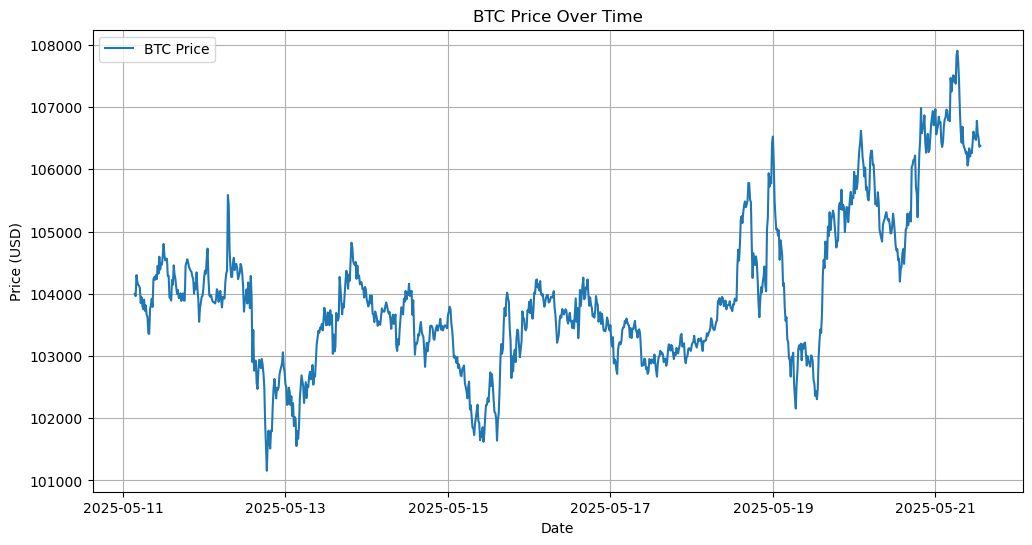

In [254]:
#plot btc price
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], label='BTC Price')
plt.title('BTC Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()


In [255]:
# Ensure 'turnover' is numeric
df['turnover'] = pd.to_numeric(df['turnover'], errors='coerce')

### time bars

In [256]:
time_bars = df.copy()
time_bars.drop('turnover', axis=1, inplace=True)

In [257]:
time_bars.head()

,open,high,low,close,volume
timestamp,,,,,
2025-05-11 03:30:00,103947.0,104026.7,103748.3,104000.0,410.661
2025-05-11 03:45:00,104000.0,104161.8,103961.9,103961.9,1046.568
2025-05-11 04:00:00,103961.9,104368.0,103950.6,104299.9,1108.346
2025-05-11 04:15:00,104299.9,104327.6,104169.5,104194.0,318.963
2025-05-11 04:30:00,104194.0,104257.2,104035.4,104140.9,476.667


(array([  1.,   0.,   0.,   0.,   0.,   0.,   1.,   2.,   2.,   2.,   4.,
          7.,  11.,  18.,  14.,  40.,  50.,  68.,  88., 131., 107., 129.,
         96.,  73.,  59.,  37.,  16.,   7.,  10.,   6.,   8.,   4.,   3.,
          1.,   1.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   1.]),
 array([-0.01025906, -0.00975906, -0.00925906, -0.00875906, -0.00825906,
        -0.00775906, -0.00725906, -0.00675906, -0.00625906, -0.00575906,
        -0.00525906, -0.00475906, -0.00425906, -0.00375906, -0.00325906,
        -0.00275906, -0.00225906, -0.00175906, -0.00125906, -0.00075906,
        -0.00025906,  0.00024094,  0.00074094,  0.00124094,  0.00174094,
         0.00224094,  0.00274094,  0.00324094,  0.00374094,  0.00424094,
         0.00474094,  0.00524094,  0.00574094,  0.00624094,  0.00674094,
         0.00724094,  0.00774094,  0.00824094,  0.00874094,  0.00924094,
         0.00974094,  0.01024094,  0.01074094,  0.01124094,  0.01174094]),
 <BarContainer object of 44 artists>)

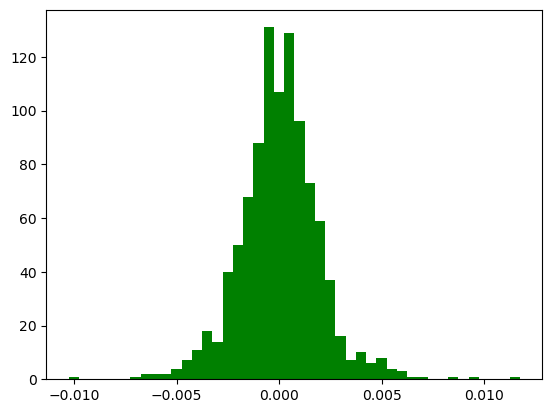

In [258]:
log_returns = np.log(time_bars['close'] / time_bars['close'].shift(1)).dropna()

bin_len = 0.0005
plt.hist(log_returns, bins=np.arange(min(log_returns), max(log_returns)+ bin_len, bin_len), color='g')

In [259]:
def bar(x, y):
    return np.int64(x/y)*y

### volume bars

In [260]:
traded_volume = 1500

volume_bars = df.groupby(bar(np.cumsum(df['volume']), traded_volume)).agg({'close': 'ohlc', 'volume': 'sum'})

# Set the index to the last timestamp of each group using the original index
volume_bars['bar_timestamp'] = df.groupby(bar(np.cumsum(df['volume']), traded_volume)).apply(lambda x: x.index[-1])
volume_bars.set_index('bar_timestamp', inplace=True)
volume_bars_price = volume_bars['close']

In [261]:
volume_bars_price.head()

,open,high,low,close
bar_timestamp,,,,
2025-05-11 03:45:00,104000.0,104000.0,103961.9,103961.9
2025-05-11 04:15:00,104299.9,104299.9,104194.0,104194.0
2025-05-11 05:00:00,104140.9,104140.9,104089.5,104089.5
2025-05-11 06:00:00,103850.0,103943.5,103750.8,103750.8
2025-05-11 06:45:00,103905.7,103905.7,103725.3,103813.1


(array([ 1.,  0.,  0.,  3.,  6.,  9., 34., 44., 61., 68., 83., 55., 64.,
        30., 19., 13.,  4.,  1.,  1.,  1.,  0.,  1.]),
 array([-0.01025906, -0.00925906, -0.00825906, -0.00725906, -0.00625906,
        -0.00525906, -0.00425906, -0.00325906, -0.00225906, -0.00125906,
        -0.00025906,  0.00074094,  0.00174094,  0.00274094,  0.00374094,
         0.00474094,  0.00574094,  0.00674094,  0.00774094,  0.00874094,
         0.00974094,  0.01074094,  0.01174094]),
 <BarContainer object of 22 artists>)

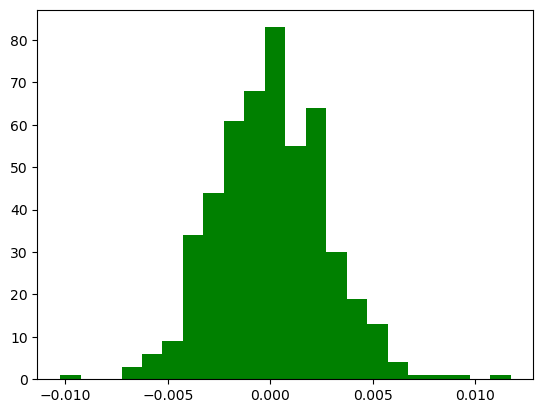

In [262]:
log_returns = np.log(volume_bars_price['close'] / volume_bars_price['close'].shift(1)).dropna()

bin_len = 0.001
plt.hist(log_returns, bins=np.arange(min(log_returns), max(log_returns)+ bin_len, bin_len), color='g')

### dollar bars

In [263]:
df.head()

,open,high,low,close,volume,turnover
timestamp,,,,,,
2025-05-11 03:30:00,103947.0,104026.7,103748.3,104000.0,410.661,4.266856e+07
2025-05-11 03:45:00,104000.0,104161.8,103961.9,103961.9,1046.568,1.089164e+08
2025-05-11 04:00:00,103961.9,104368.0,103950.6,104299.9,1108.346,1.154899e+08
2025-05-11 04:15:00,104299.9,104327.6,104169.5,104194.0,318.963,3.325510e+07
2025-05-11 04:30:00,104194.0,104257.2,104035.4,104140.9,476.667,4.964379e+07


In [264]:
turnover_value = 200000000

# Ensure 'turnover' is numeric
df['turnover'] = pd.to_numeric(df['turnover'], errors='coerce')

dollar_bars = df.groupby(bar(np.cumsum(df['turnover']), turnover_value)).agg({
    'close': 'ohlc',
    'volume': 'sum'
})

# Set the index to the last timestamp of each group using the original index
dollar_bars['bar_timestamp'] = df.groupby(bar(np.cumsum(df['turnover']), turnover_value)).apply(lambda x: x.index[-1])
dollar_bars.set_index('bar_timestamp', inplace=True)
dollar_bars_price = dollar_bars['close']

In [265]:
dollar_bars_price.head()

,open,high,low,close
bar_timestamp,,,,
2025-05-11 03:45:00,104000.0,104000.0,103961.9,103961.9
2025-05-11 05:00:00,104299.9,104299.9,104089.5,104089.5
2025-05-11 05:45:00,103850.0,103943.5,103802.0,103802.0
2025-05-11 06:45:00,103750.8,103905.7,103725.3,103813.1
2025-05-11 07:30:00,103659.2,103659.2,103363.9,103363.9


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  3.,  5.,  6.,  9., 10.,
        19., 12., 19., 23., 27., 28., 31., 27., 30., 26., 24., 23., 23.,
        24.,  9.,  7.,  8.,  6.,  5.,  4.,  2.,  3.,  0.,  0.,  1.,  0.,
         1.,  0.,  0.,  0.,  1.]),
 array([-0.01025906, -0.00975906, -0.00925906, -0.00875906, -0.00825906,
        -0.00775906, -0.00725906, -0.00675906, -0.00625906, -0.00575906,
        -0.00525906, -0.00475906, -0.00425906, -0.00375906, -0.00325906,
        -0.00275906, -0.00225906, -0.00175906, -0.00125906, -0.00075906,
        -0.00025906,  0.00024094,  0.00074094,  0.00124094,  0.00174094,
         0.00224094,  0.00274094,  0.00324094,  0.00374094,  0.00424094,
         0.00474094,  0.00524094,  0.00574094,  0.00624094,  0.00674094,
         0.00724094,  0.00774094,  0.00824094,  0.00874094,  0.00924094,
         0.00974094,  0.01024094,  0.01074094,  0.01124094,  0.01174094]),
 <BarContainer object of 44 artists>)

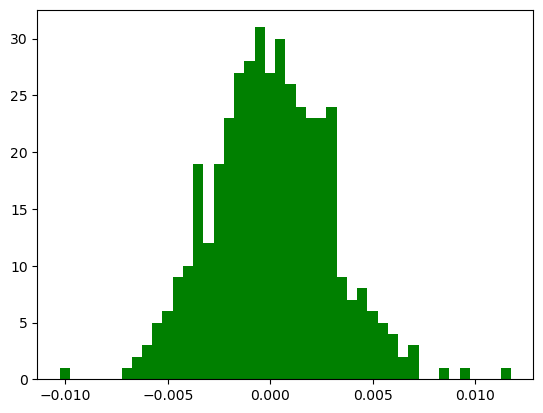

In [266]:
log_returns = np.log(dollar_bars_price['close'] / dollar_bars_price['close'].shift(1)).dropna()

bin_len = 0.0005
plt.hist(log_returns, bins=np.arange(min(log_returns), max(log_returns)+ bin_len, bin_len), color='g')

In [267]:
def count_bars_per_day(series):
    # Ensure the index is datetime
    if not isinstance(series.index, pd.DatetimeIndex):
        series = series.copy()
        series.index = pd.to_datetime(series.index)
    # Group by date and count
    daily_counts = series.groupby(series.index.date).size()
    return daily_counts


In [268]:
def count_bars_per_4hours(df):
    # Ensure the index is datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df = df.copy()
        df.index = pd.to_datetime(df.index)
    # Group by 4-hour intervals and count
    counts = df.groupby(df.index.floor('4H')).size()
    return counts


In [269]:
time_count_d = count_bars_per_day(time_bars['close'])
volume_count_d = count_bars_per_day(volume_bars_price['close'])
dollar_count_d = count_bars_per_day(dollar_bars_price['close'])

In [270]:
time_count_h = count_bars_per_4hours(time_bars)
volume_count_h = count_bars_per_4hours(volume_bars)
dollar_count_h = count_bars_per_4hours(dollar_bars)

C:\Users\HP\AppData\Local\Temp\ipykernel_22648\178008667.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  counts = df.groupby(df.index.floor('4H')).size()
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\178008667.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  counts = df.groupby(df.index.floor('4H')).size()
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\178008667.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  counts = df.groupby(df.index.floor('4H')).size()


In [271]:
count_df_d = pd.DataFrame({
    'Time Bars': time_count_d,
    'Volume Bars': volume_count_d,
    'Dollar Bars': dollar_count_d
})

<Axes: >

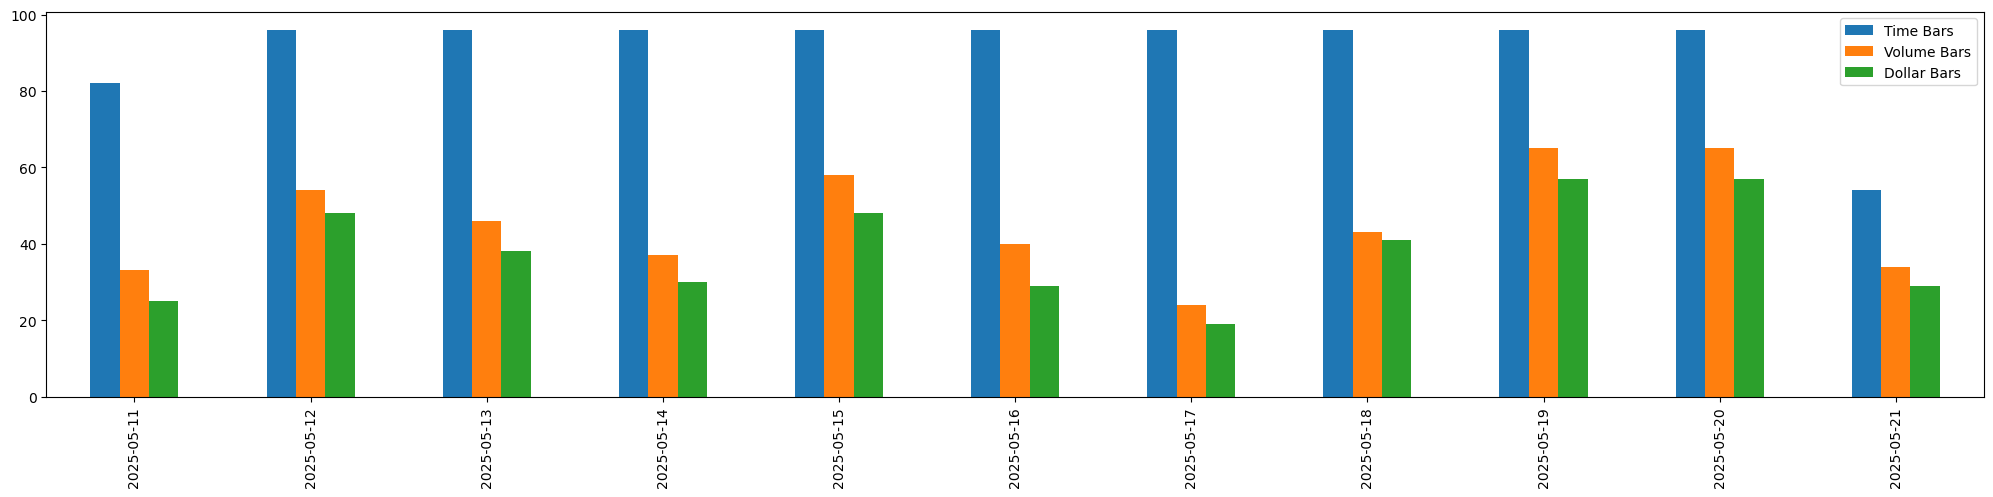

In [272]:
count_df_d.loc[:, ['Time Bars', 'Volume Bars', 'Dollar Bars']].plot(kind = 'bar', figsize=[25, 5])

In [273]:
print(count_df_d['Dollar Bars'].autocorr())
print(count_df_d['Volume Bars'].autocorr())
print(count_df_d['Time Bars'].autocorr())


0.02712168679416449
-0.007676864400633984
-0.1111111111111111


In [274]:
count_df_h = pd.DataFrame({
    'Time Bars': time_count_h,
    'Volume Bars': volume_count_h,
    'Dollar Bars': dollar_count_h
})

<Axes: >

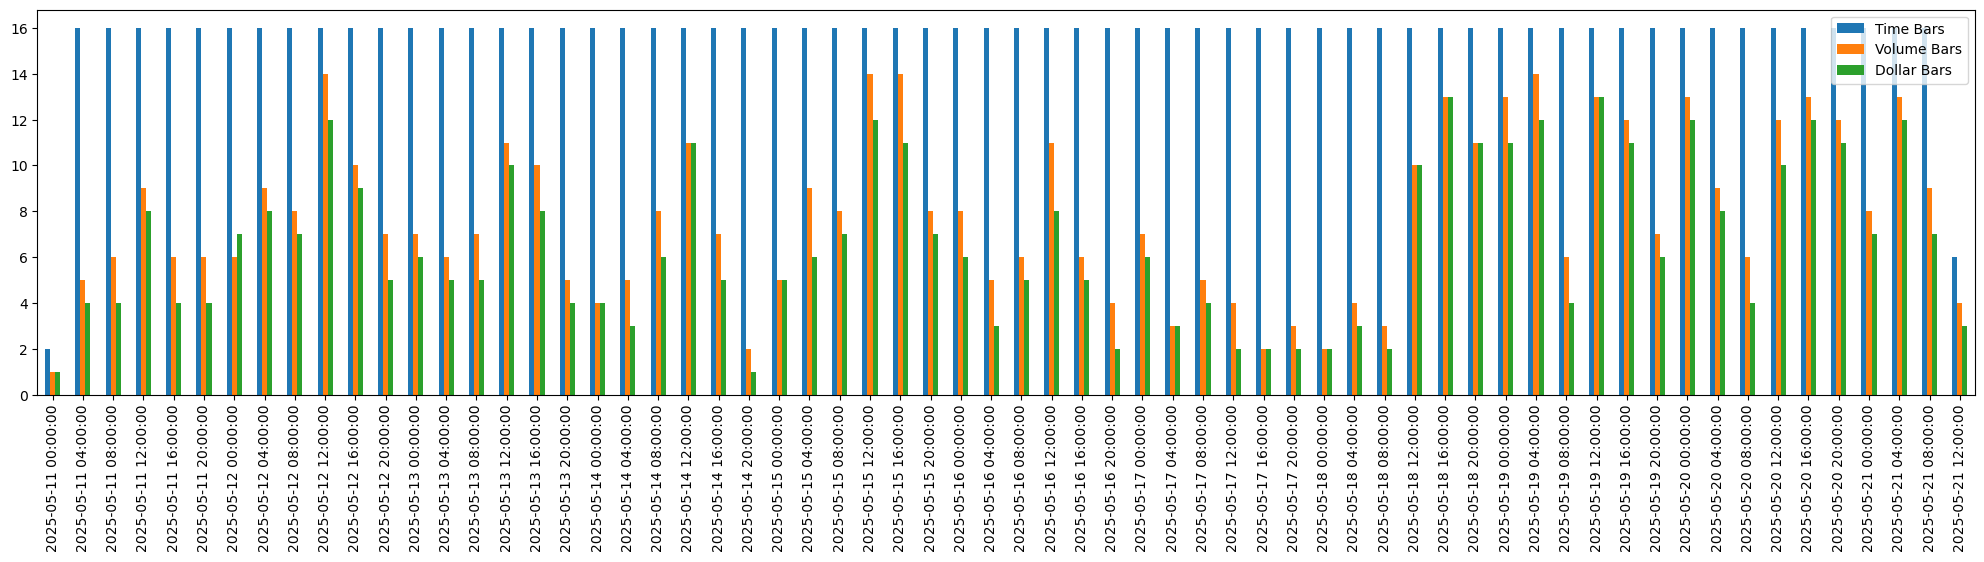

In [275]:
count_df_h.loc[:, ['Time Bars', 'Volume Bars', 'Dollar Bars']].plot(kind = 'bar', figsize=[25, 5])

In [276]:
print(count_df_h['Dollar Bars'].autocorr())
print(count_df_h['Volume Bars'].autocorr())
print(count_df_h['Time Bars'].autocorr())

0.44942220263645033
0.47977885299898054
-0.016129032258064474


dollar has slightly lower autocorrelation than volume bars, which is expected as dollar bars are more stable than volume bars.

In [277]:

db1_ = dollar_bars_price['close'].resample('4H').mean().pct_change().var()
vb1_ = volume_bars_price['close'].resample('4H').mean().pct_change().var()
tb1_ = time_bars['close'].resample('4H').mean().pct_change().var()

print(tb1_, vb1_, db1_)

2.9228507745764675e-05 3.1174165762456296e-05 3.212832945655607e-05


C:\Users\HP\AppData\Local\Temp\ipykernel_22648\2235218173.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  db1_ = dollar_bars_price['close'].resample('4H').mean().pct_change().var()
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\2235218173.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  vb1_ = volume_bars_price['close'].resample('4H').mean().pct_change().var()
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\2235218173.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tb1_ = time_bars['close'].resample('4H').mean().pct_change().var()


dollar has smaller variance than volume and time bars

In [278]:
from scipy import stats

print(stats.jarque_bera(dollar_bars_price['close'].pct_change().dropna())[0],
stats.jarque_bera(volume_bars_price['close'].pct_change().dropna())[0],
stats.jarque_bera(time_bars['close'].pct_change().dropna())[0])

8.000856061589756 17.39907547435023 402.6942431250086


dollar has lower jarque-bera value than volume and time bars

In [279]:
import statsmodels.stats.diagnostic as sm
import statsmodels.api as smi

def bband(data: pd.Series, window: int = 21, width: float = 0.005):
    avg = data.ewm(span = window).mean()
    std0 = avg * width
    lower = avg - std0
    upper = avg + std0
    
    return avg, upper, lower, std0

dollar_bars_price['avg'], dollar_bars_price['upper'], dollar_bars_price['lower'], dollar_bars_price['std0'] = bband(dollar_bars_price['close'])


count_dn = dollar_bars_price[dollar_bars_price['lower'] > dollar_bars_price['close']]
count_up = dollar_bars_price[dollar_bars_price['upper'] < dollar_bars_price['close']]
bband_dollar = pd.concat([count_dn, count_up])

raw_bbd = bband_dollar.copy()

print("Total count: {0}\nUpper Bound exceed: {1}\nLower Bound exceed: {2}".format(bband_dollar.count()[0], 
                                                                              count_up.count()[0], 
                                                                              count_dn.count()[0]))

Total count: 172
Upper Bound exceed: 103
Lower Bound exceed: 69


C:\Users\HP\AppData\Local\Temp\ipykernel_22648\3710406676.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Total count: {0}\nUpper Bound exceed: {1}\nLower Bound exceed: {2}".format(bband_dollar.count()[0],
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\3710406676.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count_up.count()[0],
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\3710406676.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

In [286]:
def cumsum_events(df: pd.Series, limit: float):
    idx, _up, _dn = [], 0, 0
    diff = df.diff()
    for i in diff.index[1:]:
        _up, _dn = max(0, _up + diff.loc[i]), min(0, _dn + diff.loc[i])
        if _up > limit:
            _up = 0; idx.append(i)
        elif _dn < - limit:
            _dn = 0; idx.append(i)
        
    return pd.DatetimeIndex(idx)

def cumsum_events1(df: pd.Series, limit: float):
    idx, _up, _dn = [], 0, 0
    diff = df.pct_change()
    for i in diff.index[1:]:
        _up, _dn = max(0, _up + diff.loc[i]), min(0, _dn + diff.loc[i])
        if _up > limit:
            _up = 0; idx.append(i)
        elif _dn < - limit:
            _dn = 0; idx.append(i)
        
    return pd.DatetimeIndex(idx)

event = cumsum_events(bband_dollar['close'], limit = 0.005) # benchmark
event_pct = cumsum_events1(bband_dollar['close'], limit = 0.005)
event_abs = cumsum_events(bband_dollar['close'], limit = bband_dollar['std0'].mean()) # based on ewma std abs estimate 0.005

event_count0 = dollar_bars_price.reindex(event)
event_count1 = dollar_bars_price.reindex(event_abs)
event_count2 = dollar_bars_price.reindex(event_pct)

print("Total count after filter (close price): {0}".format(event_count0.count()[0]))
print("Total count after filter (absolute change): {0}".format(event_count1.count()[0]))
print("Total count after filter (pct change): {0}".format(event_count2.count()[0]))

Total count after filter (close price): 171
Total count after filter (absolute change): 41
Total count after filter (pct change): 42


C:\Users\HP\AppData\Local\Temp\ipykernel_22648\75986516.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Total count after filter (close price): {0}".format(event_count0.count()[0]))
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\75986516.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Total count after filter (absolute change): {0}".format(event_count1.count()[0]))
C:\Users\HP\AppData\Local\Temp\ipykernel_22648\75986516.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame